# 데이터 조인

In [316]:
# import pandas as pd

# airbnb_df = pd.read_csv('/Users/a2485/Desktop/프로그래머스/프로젝트 3/raw data/AB_NYC_2019.csv')
# attraction_df = pd.read_csv('/Users/a2485/Desktop/프로그래머스/프로젝트 3/raw data/nyc_attractions_verified.csv')
# station_df = pd.read_csv('/Users/a2485/Desktop/프로그래머스/프로젝트 3/raw data/nyc-transit-subway-entrance-and-exit-data.csv')
# crime_df = pd.read_csv('/Users/a2485/Desktop/프로그래머스/프로젝트 3/raw data/NYPD_Complaint_Data_Historic_20260208.csv')

In [317]:
# airbnb_df.head()

In [318]:
# attraction_df.head()

<!-- # 데이터 조인 -->

<!-- ## attraction -->

<!-- ### attraction_count_2km / 3km -->

In [319]:
# import numpy as np

# # airbnb 좌표
# airbnb_coords = airbnb_df[['latitude','longitude']].values

# # 관광지 좌표
# attraction_coords = attraction_df[['latitude','longitude']].values

In [320]:
# def haversine(lat1, lon1, lat2, lon2):
#     R = 6371  # Earth radius (km)

#     lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

#     dlat = lat2 - lat1
#     dlon = lon2 - lon1

#     a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
#     c = 2*np.arcsin(np.sqrt(a))

#     return R * c

In [321]:
# counts_2km = []
# counts_3km = []

# for lat, lon in airbnb_coords:
    
#     distances = haversine(
#         lat,
#         lon,
#         attraction_coords[:,0],
#         attraction_coords[:,1]
#     )
    
#     count_2km = np.sum(distances <= 2)
#     count_3km = np.sum(distances <= 3)
    
#     counts_2km.append(count_2km)
#     counts_3km.append(count_3km)

# airbnb_df['attraction_count_2km'] = counts_2km
# airbnb_df['attraction_count_3km'] = counts_3km

In [322]:
# airbnb_df

<!-- ### distance_to_city_center -->

In [323]:
# times_square_lat = 40.7580
# times_square_lon = -73.9855

# airbnb_df['distance_to_city_center'] = haversine(
#     airbnb_df['latitude'],
#     airbnb_df['longitude'],
#     times_square_lat,
#     times_square_lon
# )

In [324]:
# airbnb_df

<!-- ### is_manhattan -->

In [325]:
# airbnb_df['is_manhattan'] = (airbnb_df['neighbourhood_group'] == 'Manhattan').astype(int)

In [326]:
# airbnb_df

In [327]:
# airbnb_df[['attraction_count_2km','attraction_count_3km']].describe()

In [328]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(12,5))

# plt.subplot(1,2,1)
# plt.hist(airbnb_df['attraction_count_2km'], bins=30)
# plt.title('attraction_count_2km distribution')

# plt.subplot(1,2,2)
# plt.hist(airbnb_df['attraction_count_3km'], bins=30)
# plt.title('attraction_count_3km distribution')

# plt.show()

<!-- ## station -->

In [329]:
# station_df[station_df['Station Name'] == '34th St'][[
#     'Station Name',
#     'Line',
#     'Division',
#     'Route1',
#     'Route2',
#     'Route3',
#     'Station Latitude',
#     'Station Longitude'
# ]].drop_duplicates()

<!-- #### station dataset을 feature engineering용으로 정리 -->

In [330]:
# # station dataset을 feature engineering용으로 정리
# station_df = station_df[['Station Name','Station Latitude','Station Longitude']].drop_duplicates()
# # 'Station Name','Station Latitude','Station Longitude'을 기준으로 unique한 station 473개 dataset 저장

# station_df.shape

<!-- #### 지하철 좌표 배열 만들기 -->

In [331]:
# station_lat = station_df['Station Latitude'].values
# station_lon = station_df['Station Longitude'].values

<!-- ### distance_to_nearest_station -->

In [332]:
# nearest_dist = []

# for _, row in airbnb_df.iterrows():

#     dist = haversine(
#         row['latitude'],
#         row['longitude'],
#         station_lat,
#         station_lon
#     )

#     nearest_dist.append(dist.min())

# airbnb_df['distance_to_nearest_station'] = nearest_dist

In [333]:
# airbnb_df[['latitude','longitude','distance_to_nearest_station']].head()

<!-- 각 숙소마다 가장 가까운 지하철까지의 거리(km)


*   0.094923 → 약 95m
*   0.465364 → 약 465m -->

In [334]:
# airbnb_df['distance_to_nearest_station'].describe()

<!-- distance_to_nearest_station의 분포를 히스토그램으로 시각화하여 숙소의 지하철 접근성 분포를 확인하였다. 대부분의 숙소는 약 0.2km ~ 0.5km 범위 내에 위치하며, 일부 외곽 숙소는 지하철과 거리가 크게 떨어진 outlier로 나타났다. -->

In [335]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(8,5))
# sns.histplot(
#     airbnb_df[airbnb_df['distance_to_nearest_station'] < 3]['distance_to_nearest_station'],
#     bins=50,
#     kde=True
# )
# plt.xlabel('Distance to Nearest Station (km)')
# plt.title('Distribution (within 3km)')
# plt.show()

<!-- ### station_count
이미 계산한 거리 행렬을 활용해서 반경 내 역 개수 feature를 만든다 -->

In [336]:
# station_counts_300m = []
# station_counts_500m = []
# station_counts_1km = []

# for _, row in airbnb_df.iterrows():

#     dist = haversine(
#         row['latitude'],
#         row['longitude'],
#         station_lat,
#         station_lon
#     )

#     station_counts_300m.append((dist <= 0.3).sum())
#     station_counts_500m.append((dist <= 0.5).sum())
#     station_counts_1km.append((dist <= 1).sum())


# airbnb_df['station_count_300m'] = station_counts_300m
# airbnb_df['station_count_500m'] = station_counts_500m
# airbnb_df['station_count_1km'] = station_counts_1km

In [337]:
# airbnb_df[[
#     'distance_to_nearest_station',
#     'station_count_300m',
#     'station_count_500m',
#     'station_count_1km'
# ]].head()

In [338]:
# airbnb_df[[
#     'station_count_300m',
#     'station_count_500m',
#     'station_count_1km'
# ]].describe()

In [339]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# cols = [
#     'station_count_300m',
#     'station_count_500m',
#     'station_count_1km'
# ]

# plt.figure(figsize=(10,6))

# for i, col in enumerate(cols, 1):
#     plt.subplot(1,3,i)
#     sns.histplot(airbnb_df[col], bins=30)
#     plt.title(col)

# plt.tight_layout()
# plt.show()

In [340]:
# col = airbnb_df.pop('station_count_300m')
# airbnb_df.insert(
#     airbnb_df.columns.get_loc('station_count_500m'),
#     'station_count_300m',
#     col
# )

In [341]:
# airbnb_df.head()

<!-- ## crime -->

In [342]:
# from sklearn.neighbors import BallTree
# a_coords = np.radians(airbnb_df[['latitude','longitude']].values)
# crime_coords = np.radians(crime_df[['Latitude','Longitude']].values)

# crime_tree = BallTree(crime_coords, metric='haversine')

In [343]:
# earth_radius = 6371

# r05 = 0.5 / earth_radius
# r1  = 1 / earth_radius
# r2  = 2 / earth_radius

<!-- ### crime_count -->

In [344]:
# c05 = crime_tree.query_radius(a_coords, r=r05, count_only=True)
# c1  = crime_tree.query_radius(a_coords, r=r1, count_only=True)
# c2  = crime_tree.query_radius(a_coords, r=r2, count_only=True)

# airbnb_df['crime_count_0.5km'] = c05
# airbnb_df['crime_count_1km'] = c1
# airbnb_df['crime_count_2km'] = c2

<!-- ### felony_count -->

In [345]:
# felony_df = crime_df[crime_df['LAW_CAT_CD']=='FELONY']

# coords = np.radians(felony_df[['Latitude','Longitude']].values)
# tree = BallTree(coords, metric='haversine')

# f05 = tree.query_radius(a_coords, r=r05, count_only=True)
# f1  = tree.query_radius(a_coords, r=r1, count_only=True)
# f2  = tree.query_radius(a_coords, r=r2, count_only=True)

# airbnb_df['felony_count_0.5km'] = f05
# airbnb_df['felony_count_1km'] = f1
# airbnb_df['felony_count_2km'] = f2

<!-- ### misdemeanor_count -->

In [346]:
# mis_df = crime_df[crime_df['LAW_CAT_CD']=='MISDEMEANOR']

# coords = np.radians(mis_df[['Latitude','Longitude']].values)
# tree = BallTree(coords, metric='haversine')

# m05 = tree.query_radius(a_coords, r=r05, count_only=True)
# m1  = tree.query_radius(a_coords, r=r1, count_only=True)
# m2  = tree.query_radius(a_coords, r=r2, count_only=True)

# airbnb_df['misdemeanor_count_0.5km'] = m05
# airbnb_df['misdemeanor_count_1km'] = m1
# airbnb_df['misdemeanor_count_2km'] = m2

<!-- ### night_crime_count -->

In [347]:
# crime_df['CMPLNT_FR_TM'] = pd.to_datetime(crime_df['CMPLNT_FR_TM'],format='%H:%M:%S',errors='coerce')
# crime_df['hour'] = crime_df['CMPLNT_FR_TM'].dt.hour

# night_df = crime_df[(crime_df['hour']>=22)|(crime_df['hour']<6)]

# coords = np.radians(night_df[['Latitude','Longitude']].values)
# tree = BallTree(coords, metric='haversine')

# n05 = tree.query_radius(a_coords, r=r05, count_only=True)
# n1  = tree.query_radius(a_coords, r=r1, count_only=True)
# n2  = tree.query_radius(a_coords, r=r2, count_only=True)

# airbnb_df['night_crime_count_0.5km'] = n05
# airbnb_df['night_crime_count_1km'] = n1
# airbnb_df['night_crime_count_2km'] = n2

<!-- ### ratio 계산 -->

In [348]:
# for r in ['0.5km','1km','2km']:

#     airbnb_df[f'felony_ratio_{r}'] = airbnb_df[f'felony_count_{r}'] / airbnb_df[f'crime_count_{r}']
#     airbnb_df[f'misdemeanor_ratio_{r}'] = airbnb_df[f'misdemeanor_count_{r}'] / airbnb_df[f'crime_count_{r}']
#     airbnb_df[f'night_crime_ratio_{r}'] = airbnb_df[f'night_crime_count_{r}'] / airbnb_df[f'crime_count_{r}']

In [349]:
# pd.set_option('display.max_columns', None)

<!-- # 최종 airbnb_df -->

In [350]:
# airbnb_df.head()

In [351]:
# airbnb_df.isnull().sum().loc[lambda x: x > 0]

In [352]:
import pandas as pd
import numpy as np

airbnb_df = pd.read_csv('/Users/junhapark/data-science-workspace/projects/airbnb-price-prediction/data/processed/aribnb_final_df.csv')

# 데이터 전처리

In [353]:
num_cols = airbnb_df.select_dtypes(include=np.number).columns.tolist()
display(airbnb_df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.000000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.000000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.499790,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.244420,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.000000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.000000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.000000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.010000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.000000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.000000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [354]:
import matplotlib.pyplot as plt
import seaborn as sns 



===== price quantile =====
0.00        0.0
0.01       30.0
0.05       40.0
0.25       69.0
0.50      106.0
0.75      175.0
0.95      355.0
0.99      799.0
1.00    10000.0
Name: price, dtype: float64


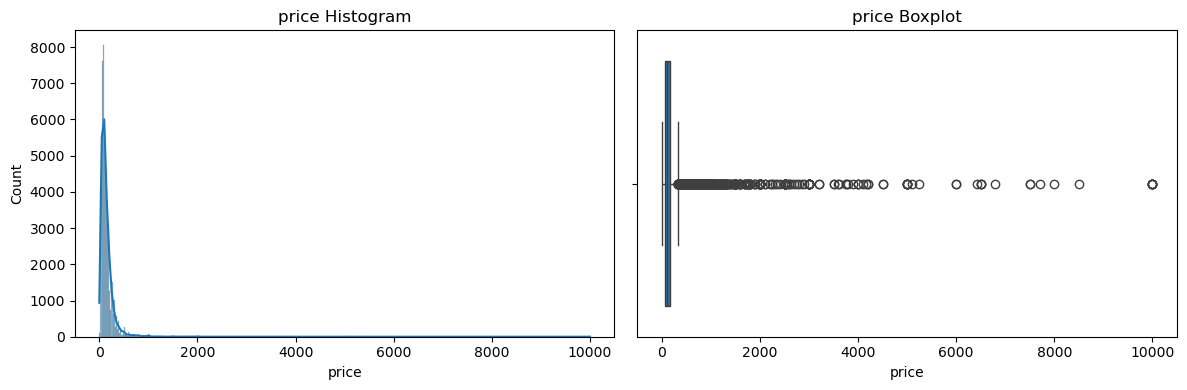


===== minimum_nights quantile =====
0.00       1.0
0.01       1.0
0.05       1.0
0.25       1.0
0.50       3.0
0.75       5.0
0.95      30.0
0.99      45.0
1.00    1250.0
Name: minimum_nights, dtype: float64


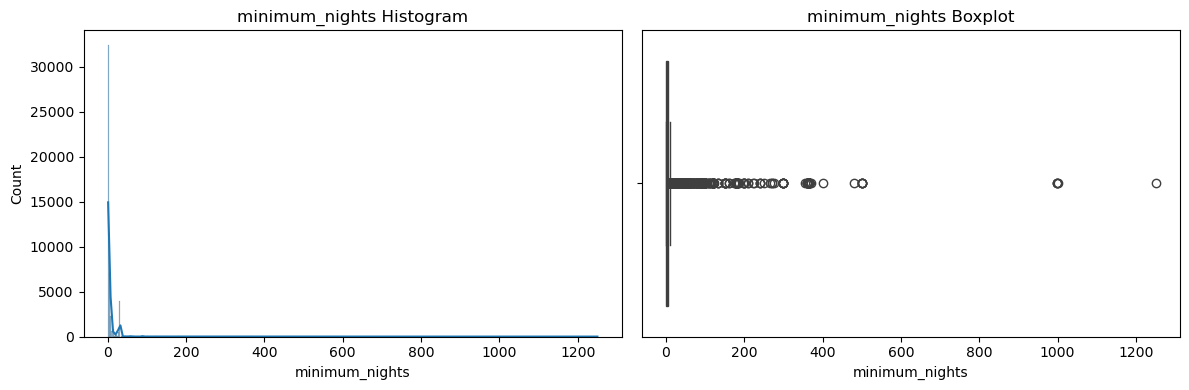


===== number_of_reviews quantile =====
0.00      0.0
0.01      0.0
0.05      0.0
0.25      1.0
0.50      5.0
0.75     24.0
0.95    114.0
0.99    214.0
1.00    629.0
Name: number_of_reviews, dtype: float64


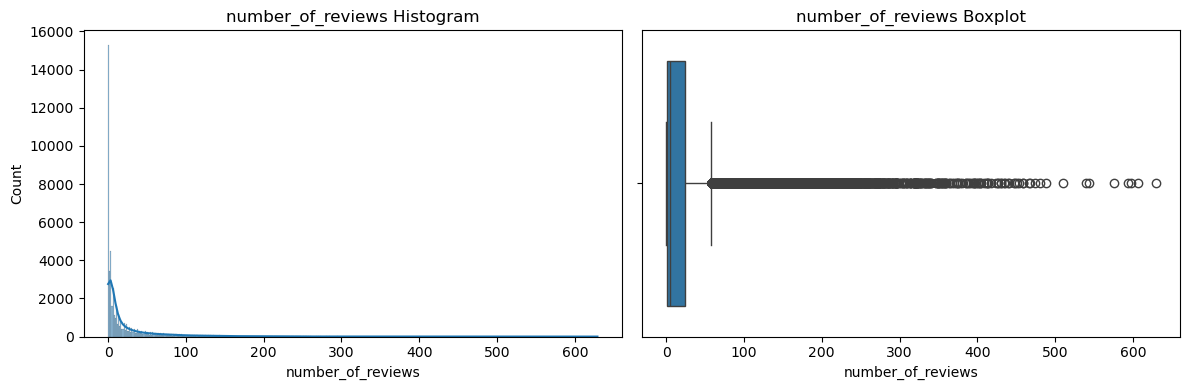


===== reviews_per_month quantile =====
0.00     0.0100
0.01     0.0200
0.05     0.0400
0.25     0.1900
0.50     0.7200
0.75     2.0200
0.95     4.6400
0.99     7.1958
1.00    58.5000
Name: reviews_per_month, dtype: float64


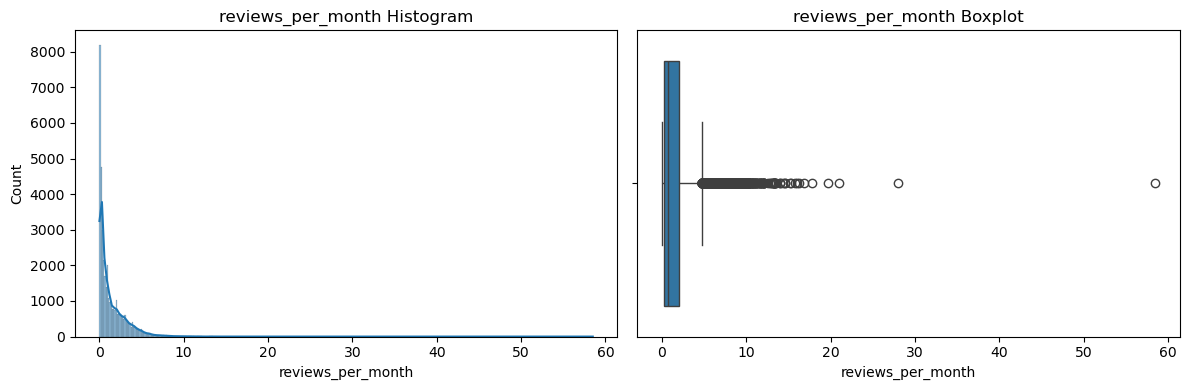

In [355]:
check_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']

for col in check_cols:
    if col in airbnb_df.columns:
        print(f'\n===== {col} quantile =====')
        print(airbnb_df[col].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(airbnb_df[col], kde=True, ax=axes[0])
        axes[0].set_title(f'{col} Histogram')
        sns.boxplot(x=airbnb_df[col], ax=axes[1])
        axes[1].set_title(f'{col} Boxplot')
        plt.tight_layout()
        plt.show()

In [356]:
skew_df = pd.DataFrame({
    'skewness': airbnb_df[num_cols].skew()
}).sort_values(by='skewness', ascending=False)
display(skew_df)

,skewness
minimum_nights,21.827275
price,19.118939
distance_to_nearest_station,9.407781
calculated_host_listings_count,7.933174
number_of_reviews,3.690635
station_count_300m,3.384947
reviews_per_month,3.130189
station_count_500m,2.920116
station_count_1km,1.779903
attraction_count_2km,1.409347


## 결측치 처리

In [357]:
airbnb_df.isnull().sum().loc[lambda x: x > 0]

name                          16
host_name                     21
last_review                10052
reviews_per_month          10052
felony_ratio_0.5km             5
misdemeanor_ratio_0.5km        5
night_crime_ratio_0.5km        5
dtype: int64

### name / host_name 결측치 처리

In [358]:
airbnb_df = airbnb_df.drop(columns=['name'])
airbnb_df = airbnb_df.drop(columns=['host_name'])

### last_review 결측치 처리

In [359]:
airbnb_df = airbnb_df.drop(columns=['last_review'])

### reviews_per_month

In [360]:
airbnb_df['reviews_per_month'] = airbnb_df['reviews_per_month'].fillna(0)

### crime ratio 결측치 처리

In [361]:
airbnb_df[
    (airbnb_df['crime_count_0.5km'] == 0) &
    (airbnb_df['felony_count_0.5km'] > 0)
]

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,...,night_crime_count_2km,felony_ratio_0.5km,misdemeanor_ratio_0.5km,night_crime_ratio_0.5km,felony_ratio_1km,misdemeanor_ratio_1km,night_crime_ratio_1km,felony_ratio_2km,misdemeanor_ratio_2km,night_crime_ratio_2km


In [362]:
ratio_cols = [
    'felony_ratio_0.5km',
    'misdemeanor_ratio_0.5km',
    'night_crime_ratio_0.5km'
]

airbnb_df[ratio_cols] = airbnb_df[ratio_cols].fillna(0)

In [363]:
airbnb_df.isnull().sum().loc[lambda x: x > 0]

Series([], dtype: int64)

## 이상치 처리

In [364]:
airbnb_df = airbnb_df[airbnb_df['price'] > 0]

price_upper = airbnb_df['price'].quantile(0.99)
airbnb_df = airbnb_df[airbnb_df['price'] <= price_upper]

In [365]:
upper = airbnb_df['minimum_nights'].quantile(0.99)
airbnb_df = airbnb_df[airbnb_df['minimum_nights'] <= upper]


===== price quantile =====
0.00     10.0
0.01     30.0
0.05     40.0
0.25     69.0
0.50    105.0
0.75    175.0
0.95    345.0
0.99    550.0
1.00    799.0
Name: price, dtype: float64


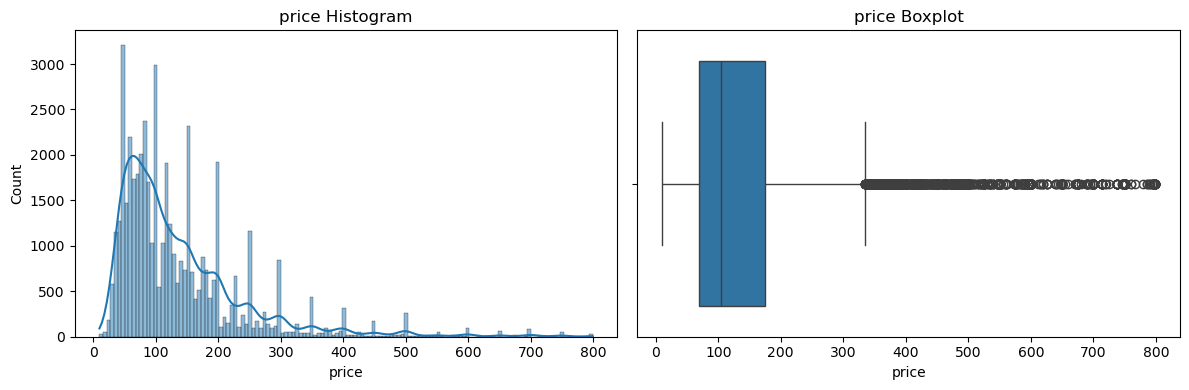


===== minimum_nights quantile =====
0.00     1.0
0.01     1.0
0.05     1.0
0.25     1.0
0.50     2.0
0.75     5.0
0.95    30.0
0.99    30.0
1.00    40.0
Name: minimum_nights, dtype: float64


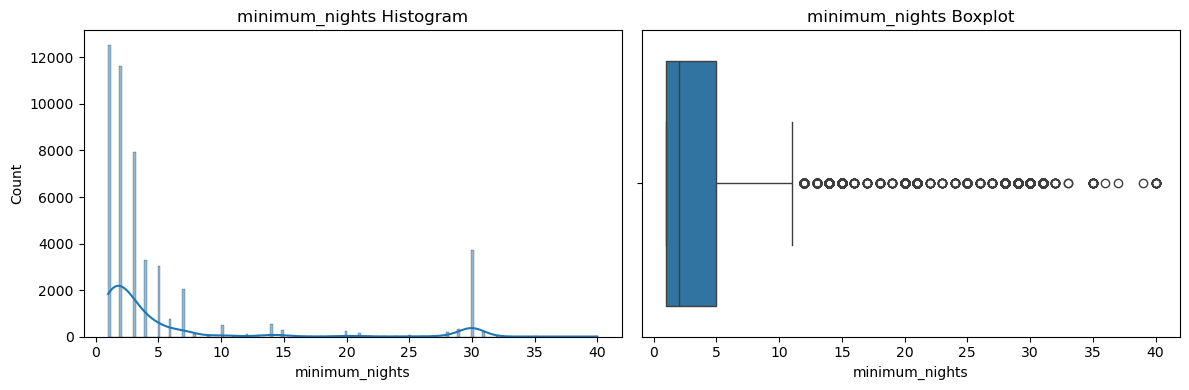


===== number_of_reviews quantile =====
0.00      0.0
0.01      0.0
0.05      0.0
0.25      1.0
0.50      5.0
0.75     24.0
0.95    115.0
0.99    214.0
1.00    629.0
Name: number_of_reviews, dtype: float64


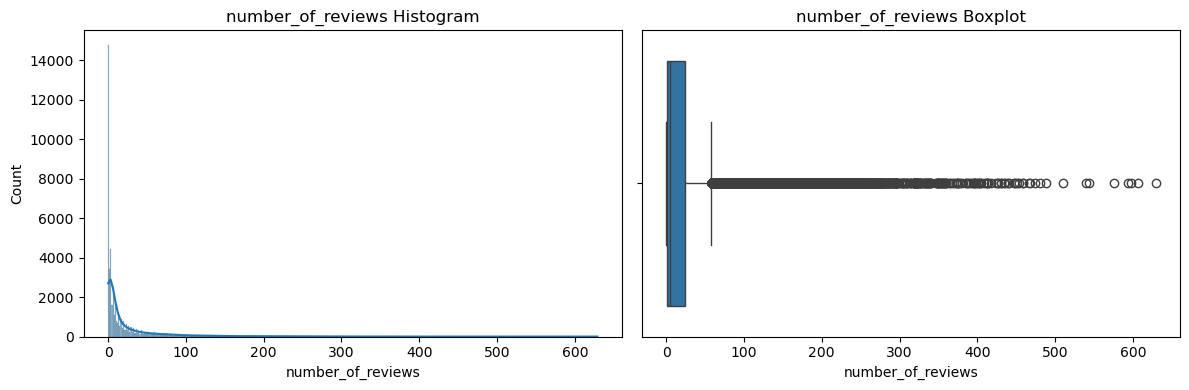


===== reviews_per_month quantile =====
0.00     0.0000
0.01     0.0000
0.05     0.0000
0.25     0.0400
0.50     0.3800
0.75     1.6200
0.95     4.3400
0.99     6.8373
1.00    58.5000
Name: reviews_per_month, dtype: float64


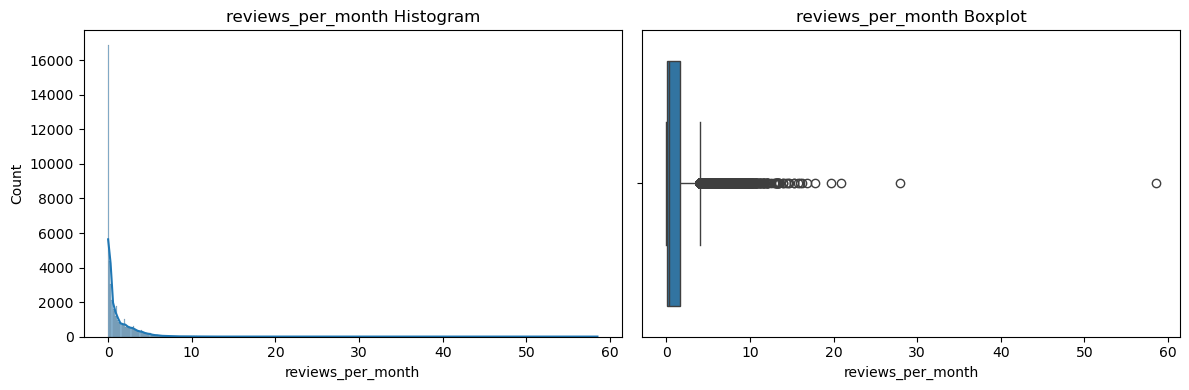

In [366]:
check_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']

for col in check_cols:
    if col in airbnb_df.columns:
        print(f'\n===== {col} quantile =====')
        print(airbnb_df[col].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(airbnb_df[col], kde=True, ax=axes[0])
        axes[0].set_title(f'{col} Histogram')
        sns.boxplot(x=airbnb_df[col], ax=axes[1])
        axes[1].set_title(f'{col} Boxplot')
        plt.tight_layout()
        plt.show()

In [367]:
skew_df = pd.DataFrame({
    'skewness': airbnb_df[num_cols].skew()
}).sort_values(by='skewness', ascending=False)
display(skew_df)

,skewness
distance_to_nearest_station,9.316855
calculated_host_listings_count,7.910868
number_of_reviews,3.667502
station_count_300m,3.403368
reviews_per_month,3.285039
station_count_500m,2.928943
minimum_nights,2.297880
price,2.273991
station_count_1km,1.794295
attraction_count_2km,1.434235


## log 변환

In [368]:
import numpy as np

log_cols = [
    'minimum_nights',
    'distance_to_nearest_station',
    'calculated_host_listings_count',
    'number_of_reviews',
    'reviews_per_month',
    'station_count_300m',
    'station_count_500m',
    'price'
]

# 1. 로그 변환 전/후 왜도 비교를 저장할 리스트
skew_rows = []

for col in log_cols:
    if col in airbnb_df.columns:
        before_skew = airbnb_df[col].skew()

        # 로그 컬럼 생성
        airbnb_df[f'log_{col}'] = np.log1p(airbnb_df[col])

        after_skew = airbnb_df[f'log_{col}'].skew()

        skew_rows.append({
            'feature': col,
            'skew_before': before_skew,
            'skew_after_log': after_skew
        })

# 2. 왜도 비교 결과 확인
skew_df = pd.DataFrame(skew_rows)
display(skew_df)

# 3. 원본 컬럼은 드롭하지 않고 그대로 유지
airbnb_df.head()



,feature,skew_before,skew_after_log
0,minimum_nights,2.297880,1.305045
1,distance_to_nearest_station,9.316855,3.678378
2,calculated_host_listings_count,7.910868,3.284579
3,number_of_reviews,3.667502,0.353813
4,reviews_per_month,3.285039,0.933286
5,station_count_300m,3.403368,0.821946
6,station_count_500m,2.928943,0.248688
7,price,2.273991,0.237122


,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,...,misdemeanor_ratio_2km,night_crime_ratio_2km,log_minimum_nights,log_distance_to_nearest_station,log_calculated_host_listings_count,log_number_of_reviews,log_reviews_per_month,log_station_count_300m,log_station_count_500m,log_price
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,...,0.515096,0.242109,0.693147,0.382104,1.945910,2.302585,0.190620,0.000000,0.693147,5.010635
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,...,0.540041,0.205736,0.693147,0.090684,1.098612,3.828641,0.322083,1.386294,1.945910,5.420535
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,...,0.578210,0.206138,1.386294,0.287966,0.693147,0.000000,0.000000,0.000000,0.693147,5.017280
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,...,0.524755,0.221725,0.693147,0.347774,0.693147,5.602119,1.729884,0.000000,1.098612,4.499810
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,...,0.571406,0.205123,2.397895,0.182477,0.693147,2.302585,0.095310,0.693147,1.098612,4.394449


In [369]:
airbnb_df.columns

Index(['id', 'host_id', 'neighbourhood_group', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'attraction_count_2km', 'attraction_count_3km',
       'distance_to_city_center', 'is_manhattan',
       'distance_to_nearest_station', 'station_count_300m',
       'station_count_500m', 'station_count_1km', 'crime_count_0.5km',
       'crime_count_1km', 'crime_count_2km', 'felony_count_0.5km',
       'felony_count_1km', 'felony_count_2km', 'misdemeanor_count_0.5km',
       'misdemeanor_count_1km', 'misdemeanor_count_2km',
       'night_crime_count_0.5km', 'night_crime_count_1km',
       'night_crime_count_2km', 'felony_ratio_0.5km',
       'misdemeanor_ratio_0.5km', 'night_crime_ratio_0.5km',
       'felony_ratio_1km', 'misdemeanor_ratio_1km', 'night_crime_ratio_1km',
       'felony_ratio_2km', 'misdemeanor_ratio_2km', 'night_crime_rati

In [370]:
cols_to_drop = ['neighbourhood', 'latitude', 'longitude']
cols_to_drop = [col for col in cols_to_drop if col in airbnb_df.columns]

airbnb_df = airbnb_df.drop(columns=cols_to_drop)

print("drop 후 컬럼:")
print(airbnb_df.columns)


drop 후 컬럼:
Index(['id', 'host_id', 'neighbourhood_group', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'attraction_count_2km', 'attraction_count_3km',
       'distance_to_city_center', 'is_manhattan',
       'distance_to_nearest_station', 'station_count_300m',
       'station_count_500m', 'station_count_1km', 'crime_count_0.5km',
       'crime_count_1km', 'crime_count_2km', 'felony_count_0.5km',
       'felony_count_1km', 'felony_count_2km', 'misdemeanor_count_0.5km',
       'misdemeanor_count_1km', 'misdemeanor_count_2km',
       'night_crime_count_0.5km', 'night_crime_count_1km',
       'night_crime_count_2km', 'felony_ratio_0.5km',
       'misdemeanor_ratio_0.5km', 'night_crime_ratio_0.5km',
       'felony_ratio_1km', 'misdemeanor_ratio_1km', 'night_crime_ratio_1km',
       'felony_ratio_2km', 'misdemeanor_ratio_2km', 'night_crime_ratio_2km',
       'log_minimum_nights', '

In [371]:
airbnb_df.columns

Index(['id', 'host_id', 'neighbourhood_group', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'attraction_count_2km', 'attraction_count_3km',
       'distance_to_city_center', 'is_manhattan',
       'distance_to_nearest_station', 'station_count_300m',
       'station_count_500m', 'station_count_1km', 'crime_count_0.5km',
       'crime_count_1km', 'crime_count_2km', 'felony_count_0.5km',
       'felony_count_1km', 'felony_count_2km', 'misdemeanor_count_0.5km',
       'misdemeanor_count_1km', 'misdemeanor_count_2km',
       'night_crime_count_0.5km', 'night_crime_count_1km',
       'night_crime_count_2km', 'felony_ratio_0.5km',
       'misdemeanor_ratio_0.5km', 'night_crime_ratio_0.5km',
       'felony_ratio_1km', 'misdemeanor_ratio_1km', 'night_crime_ratio_1km',
       'felony_ratio_2km', 'misdemeanor_ratio_2km', 'night_crime_ratio_2km',
       'log_minimum_nights', 'log_distanc

In [372]:
from pathlib import Path

output_path = Path('../data/processed/airbnb_preprocessed_df.csv')
airbnb_df.to_csv(output_path, index=False)

print(f'Saved preprocessed data to: {output_path.resolve()}')
print(airbnb_df.shape)


Saved preprocessed data to: /Users/junhapark/data-science-workspace/projects/airbnb-price-prediction/data/processed/airbnb_preprocessed_df.csv
(47928, 47)
